In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
np.random.seed(100)

3) Plotar um gráfico 2s

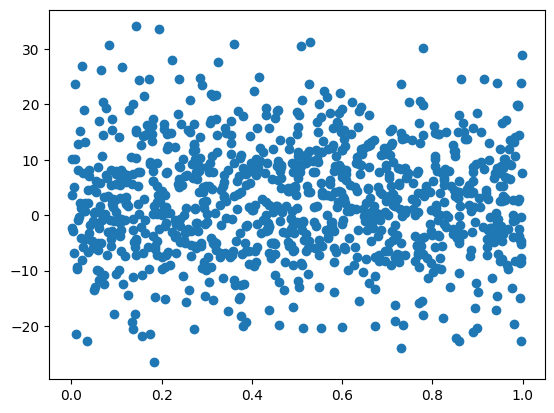

In [18]:
m = 1000
x = np.random.rand(m)
w = np.random.normal(0,1,m)
y = 1.2 + 2.3*x + 10*w

plt.scatter(x,y)
plt.show()

4. Plotando histograma

<function matplotlib.pyplot.show(close=None, block=None)>

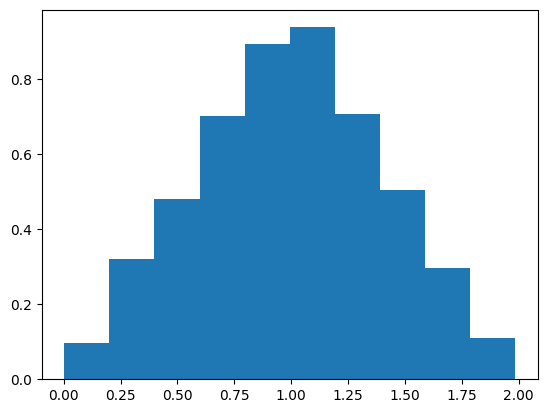

In [ ]:
m = 10000
x = np.random.rand(m)
y = np.random.rand(m)
z = x + y # teorema do limite central*
plt.hist(z, density=True) # density garante que a área abaixo do histograma seja 1
plt.show


5. Gráfico 3D

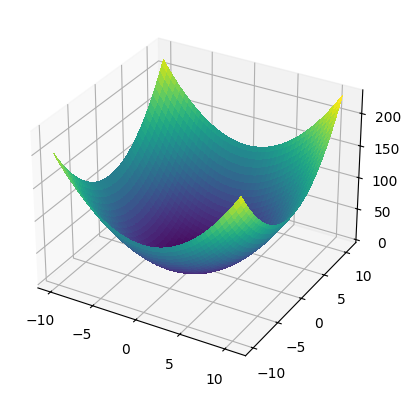

In [55]:
from matplotlib import cm
x1 = np.arange(-10,11,0.25)
x2 = np.arange(-10,11,0.25)
x1, x2 = np.meshgrid(x1,x2)
y = x1**2 + x2**2

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

ax.plot_surface(x1,x2,y,cmap=cm.viridis,
                       linewidth=0, antialiased=False) #ploting the surface   

plt.show()

6. concatenando 

In [58]:
a1 = np.array([0,1,0,1])
a2 = np.array([0,0,1,1])
mat = np.c_[a1,a2] #concatenation along colums
print(mat.shape)
print(mat)

(4, 2)
[[0 0]
 [1 0]
 [0 1]
 [1 1]]


7. modulador


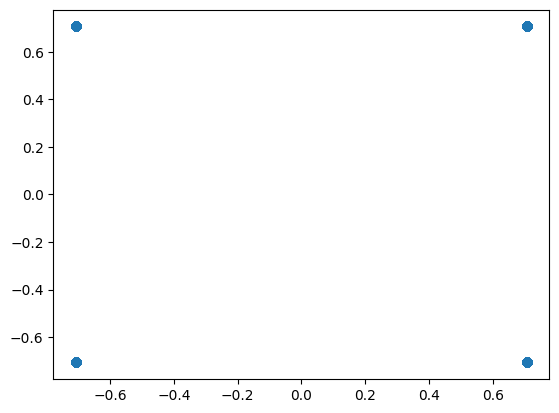

In [2]:
def modulator(val):
    complx = np.array([1/np.sqrt(2) + 1j/np.sqrt(2),
              -1/np.sqrt(2) +1j/np.sqrt(2),
              1/np.sqrt(2) - 1j/np.sqrt(2),
              -1/np.sqrt(2) - 1j/np.sqrt(2)],dtype=complex)
    
    symbols = [complex(complx[i]) for i in val]
    return symbols


n = 1000
inp = np.random.randint(0,4,n)
outp_mod = modulator(inp)
plt.scatter(np.real(outp_mod), np.imag(outp_mod)) #constelação
plt.show()

8. demodulador

In [6]:
def demodulator(c):
    """
    ISSO N FUNCIONA COM RUIDO
    dict = {1/np.sqrt(2) + 1j/np.sqrt(2) : 0,
              -1/np.sqrt(2) +1j/np.sqrt(2) : 1,
              1/np.sqrt(2) - 1j/np.sqrt(2) : 2,
              -1/np.sqrt(2) - 1j/np.sqrt(2) : 3}
    dec = [dict[chave] for chave in c]
    """
    #encontrei essa alternativa para o sinal com ruido
    complx = np.array([1/np.sqrt(2) + 1j/np.sqrt(2),
              -1/np.sqrt(2) +1j/np.sqrt(2),
              1/np.sqrt(2) - 1j/np.sqrt(2),
              -1/np.sqrt(2) - 1j/np.sqrt(2)],dtype=complex)
    
    dem = []
    for i in c:
        idx = np.argmin(np.abs(complx-i))
        dem.append(idx)
    return np.array(dem)


outp_dem = demodulator(outp_mod)
print(outp_dem)
print(set(outp_dem-inp))

[0 0 3 3 3 3 0 2 2 0 2 1 2 2 2 2 1 0 0 3 0 3 0 2 0 3 1 1 2 2 3 0 0 3 1 1 1
 3 0 0 3 3 3 3 1 3 1 1 2 3 3 3 0 2 1 1 2 3 2 3 1 3 0 2 1 2 0 3 3 1 2 0 2 0
 0 2 1 2 1 0 1 2 2 1 1 0 2 0 3 3 3 1 2 0 1 1 0 2 3 2 3 0 3 2 3 2 3 0 3 1 0
 0 3 0 1 3 2 2 2 2 2 0 3 2 1 3 0 1 2 2 2 2 0 2 3 2 3 1 0 2 2 0 3 3 1 1 0 0
 1 1 2 2 1 2 2 0 2 3 3 2 3 2 1 2 3 0 3 1 1 3 1 1 1 3 0 0 2 2 1 0 3 0 3 0 2
 0 1 0 2 0 1 2 1 3 0 0 1 1 3 0 1 0 2 0 2 0 1 3 2 2 3 2 2 2 1 0 1 2 3 1 0 0
 0 1 2 0 2 2 3 2 2 3 1 2 3 1 1 2 2 1 0 2 1 2 3 0 1 2 2 1 2 1 1 1 1 2 3 0 2
 3 1 0 2 0 2 3 1 3 3 0 2 1 2 1 1 1 2 1 0 3 0 3 2 3 3 2 0 2 1 0 2 1 0 0 1 1
 3 2 2 3 1 0 2 1 2 0 3 0 1 1 1 3 2 3 2 3 1 1 0 1 3 2 1 0 0 1 3 1 2 0 3 2 0
 3 3 3 1 1 2 0 3 2 1 0 2 0 2 0 1 1 1 2 2 0 2 1 0 0 3 0 1 1 0 3 0 2 1 0 3 1
 0 2 0 3 3 2 1 1 2 3 0 3 2 0 3 3 2 3 0 3 3 2 3 0 0 0 1 1 3 1 0 3 2 3 0 0 0
 1 3 3 1 1 0 3 2 2 0 3 0 1 0 1 3 1 1 3 0 3 2 1 2 3 3 0 0 2 2 1 1 0 2 0 3 0
 3 1 3 2 2 2 3 2 2 1 0 1 3 3 0 1 3 0 2 2 0 0 1 0 1 2 1 2 0 3 3 3 3 3 0 1 1
 2 0 1 3 1 0 1 3 2 3 2 2 

9. Implementei a função do site abaixo (usei B e Rs = 1, arbitrariamente)

Es/No is a way to specify the signal-to-noise ratio (SNR) of a digital communications signal.

Es -> energy per symbol

S -> avg power per sample

K -> input signal's length 

N0 -> spectral density

B -> the bandwidth of the channel (??)

Rs -> the symbol rate (??)

https://tomroelandts.com/articles/how-to-add-noise-to-set-a-digital-communications-signal-to-a-given-esn0#:~:text=The%20Question%20Concretely%2C%20this%20article%20answers%20the,N%200%20is%20the%20noise%20spectral%20density.


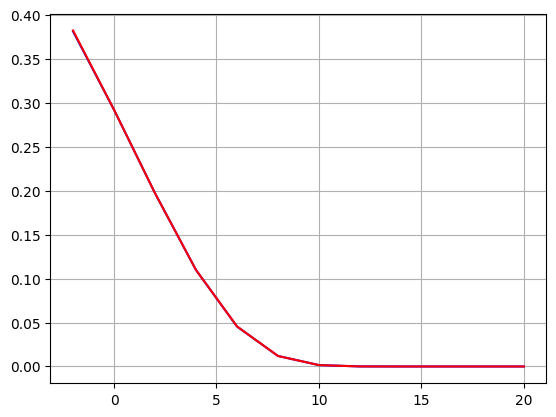

In [25]:
def add_noise(s, EsN0, B, Rs):
    K = len(s)  # n° de symbols no sinal de entrada
    S = np.sum(np.abs(s) ** 2) / K  # descrita no link acima
 
    n_real = np.random.normal(0, 1, K)
    n_imag = np.random.normal(0, 1, K)
 
    n = np.sqrt(S * B / (2 * EsN0 * Rs)) * (n_real + 1j * n_imag) # descrita no link acima
 
    return s + n

n = 1000000
vetor = np.random.randint(0,4,n)
vetor_symbols = modulator(vetor)
EsN0_dB = np.arange(-2,21,2)
EsN0 = 10 ** (EsN0_dB / 10)  #conversão db -> linear

ser = np.empty(len(EsN0))
theoretical_ser = np.empty(len(EsN0))
for i in range(len(EsN0)):
    vetor_symbols_ruido = add_noise(vetor_symbols,EsN0[i],1,1)
    vetor_aprox = demodulator(vetor_symbols_ruido)
    ser[i] = np.count_nonzero(vetor_aprox - vetor)/len(vetor)
    theoretical_ser[i] = math.erfc(np.sqrt(EsN0[i]/2)) - 0.25 * math.erfc(np.sqrt(EsN0[i]/2)) ** 2

plt.plot(EsN0_dB,theoretical_ser,color='b',label='teorico')
plt.plot(EsN0_dB,ser,color='red',label='simulado')
plt.grid(True)
plt.show()


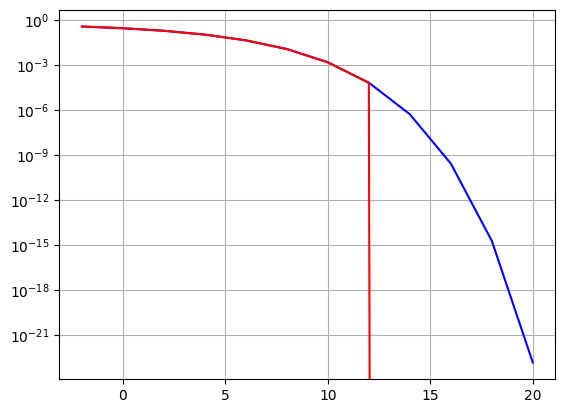

In [26]:
plt.semilogy(EsN0_dB,theoretical_ser,color='b',label='teorico')
plt.semilogy(EsN0_dB,ser,color='red',label='simulado')
plt.grid(True)
plt.show()